# Kanji Recognizer Model Training

## (GPU Server) Training 

The code as it is needs to have GPU access and a decent RAM. If your PC resources aren't good enough reduce the batch size when training, or try to load unload the datasets in batches


In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import io
import gc

drive.mount('/content/drive', force_remount = True)
df = pd.read_parquet('/content/drive/MyDrive/ETL9B/ETL9B_ExtendedCentered.parquet')
print(df.tail())

Mounted at /content/drive
       char                                         image_data
625887    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625888    ヴ  b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625889    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625890    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625891    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...


### Data Analyzing

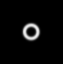

--- Label Distribution ---
      Count  Percentage
char                   
エ       206    0.032913
ウ       206    0.032913
イ       206    0.032913
ア       206    0.032913
」       206    0.032913
...     ...         ...
砕       201    0.032114
砦       201    0.032114
祭       201    0.032114
斎       201    0.032114
彩       201    0.032114

[3112 rows x 2 columns]


In [2]:
#610236 Examples
#3036 Classes
#201 Examples per Class
#64x63 Image Size

def DisplayImage(id):
    bytes = df.iloc[id]['image_data']
    image = Image.open(io.BytesIO(bytes))
    display(image)
    
def AnalyzeLabels():
    counts = df["char"].value_counts()
    percent = df["char"].value_counts(normalize=True) * 100
    
     
    print("--- Label Distribution ---")
    tempdf = pd.DataFrame({'Count': counts, 'Percentage': percent})
    print(tempdf)
        
DisplayImage(610236 + 300 )
AnalyzeLabels()



### Dictionary Save/Load
Will be usefull later on when building a guessing App

In [3]:
def SaveDictionary():
    unique = df['char'].unique()
    print(len(unique))
    c2n = {i: char for i, char in enumerate(unique)}

    with open('/content/drive/MyDrive/ETL9B/Class2Number.json', 'w') as f:
        json.dump(c2n, f)
        
def LoadDictionary() -> tuple[dict[int, str], dict[str, int]]: 
    with open('/content/drive/MyDrive/ETL9B/Class2Number.json', 'r') as f:
        c2n = json.load(f)
        
    return c2n, {v: k for k, v in c2n.items()}

#SaveDictionary()
Number2Letter, Letter2Number = LoadDictionary()

print(Number2Letter)
print(Number2Letter.get("0")) #Can't put it as integer for some reason #But it doesnt matter let's just roll with it
print(Letter2Number)


{'0': 'あ', '1': 'い', '2': 'う', '3': 'え', '4': 'お', '5': 'か', '6': 'が', '7': 'き', '8': 'ぎ', '9': 'く', '10': 'ぐ', '11': 'け', '12': 'げ', '13': 'こ', '14': 'ご', '15': 'さ', '16': 'ざ', '17': 'し', '18': 'じ', '19': 'す', '20': 'ず', '21': 'せ', '22': 'ぜ', '23': 'そ', '24': 'ぞ', '25': 'た', '26': 'だ', '27': 'ち', '28': 'ぢ', '29': 'つ', '30': 'づ', '31': 'て', '32': 'で', '33': 'と', '34': 'ど', '35': 'な', '36': 'に', '37': 'ぬ', '38': 'ね', '39': 'の', '40': 'は', '41': 'ば', '42': 'ぱ', '43': 'ひ', '44': 'び', '45': 'ぴ', '46': 'ふ', '47': 'ぶ', '48': 'ぷ', '49': 'へ', '50': 'べ', '51': 'ぺ', '52': 'ほ', '53': 'ぼ', '54': 'ぽ', '55': 'ま', '56': 'み', '57': 'む', '58': 'め', '59': 'も', '60': 'や', '61': 'ゆ', '62': 'よ', '63': 'ら', '64': 'り', '65': 'る', '66': 'れ', '67': 'ろ', '68': 'わ', '69': 'を', '70': 'ん', '71': '亜', '72': '唖', '73': '娃', '74': '阿', '75': '哀', '76': '愛', '77': '挨', '78': '姶', '79': '逢', '80': '葵', '81': '茜', '82': '穐', '83': '悪', '84': '握', '85': '渥', '86': '旭', '87': '葦', '88': '芦', '89': '鯵', '90': '梓', '91': '圧

### Processing DataFrame for CNN

In [4]:


def BinaryImageProcessing(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('L')
    img = img.resize((63, 64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=-1)
    return img_array.astype(np.float16) 

def CharacterProcessing(c):
    return Letter2Number[c]

df["label"] = df["char"].apply(CharacterProcessing) #To be Done: Drop char column (actually no need for it)
df["label"] = df["label"].astype(np.int16)

df['image_data'] = df['image_data'].apply(BinaryImageProcessing)


### Split Formation

In [5]:


train_df, temp_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['label']
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 500713
Validation size: 62589
Test size: 62590


In [6]:
def CheckProportions():
    for df, name in zip([train_df, val_df, test_df], ["Train", "Validation", "Test"]):
        prop = df["label"].value_counts(normalize=True).head(3)
        print(f"Proportions in {name}:")
        print(prop)
        print("\n")

CheckProportions()

Proportions in Train:
label
3099    0.000328
3049    0.000328
3091    0.000328
Name: proportion, dtype: float64


Proportions in Validation:
label
284     0.000336
1959    0.000336
2198    0.000336
Name: proportion, dtype: float64


Proportions in Test:
label
2532    0.000336
2998    0.000336
3098    0.000336
Name: proportion, dtype: float64




### Model Building

In [7]:
#Don't train this on CPU it will take forever
#It took me 50min on Colab Pro GPUs
with tf.device('/GPU:0'):
    model = models.Sequential([
        layers.Input(shape=(64, 63, 1)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(3112, activation='softmax') # 3112 classes
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'drive/MyDrive/ETL9B/TheGOAT.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 63, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14336)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    14,681,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3112)           │     3,189,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,242,344 (69.59 MB)

 Trainable params: 18,241,448 (69.59 MB)

 Non-trainable params: 896 (3.50 KB)

### Separating Image and Labels

In [8]:
#We can prob do this a bit earlier, feels off to do it here
#Check DataLoaders? 

train_X = np.stack(train_df['image_data'].values)
train_y = train_df['label'].values

val_X = np.stack(val_df['image_data'].values)
val_y = val_df['label'].values

test_X = np.stack(test_df['image_data'].values)
test_y = test_df['label'].values


In [9]:
#Just Freeing some memory bc we will need it

del df
del temp_df
del train_df
del val_df
del test_df

gc.collect()

13

### Model Training

In [10]:
BATCH_SIZE = 256

augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.04),
    layers.RandomTranslation(height_factor=0.07, width_factor=0.07),
    layers.RandomZoom(height_factor=(-0.1, 0.1)),
], name="augmentation")

def augment_batch(images, labels):
    return augmentation(images, training=True), labels

# Dataset tensors must live on CPU — GPU VRAM is for model weights/activations, not the full ~2GB dataset.
# The sticky GPU device context from building the model makes this explicit placement necessary.
with tf.device('/CPU:0'):
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((train_X, train_y))
        .shuffle(buffer_size=10000)
        .batch(BATCH_SIZE)
        .map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_dataset = (
        tf.data.Dataset.from_tensor_slices((val_X, val_y))
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0284 - loss: 6.8194
Epoch 1: val_accuracy improved from None to 0.63321, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 1: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 219s 104ms/step - accuracy: 0.0896 - loss: 5.6401 - val_accuracy: 0.6332 - val_loss: 1.5437 - learning_rate: 0.0010
Epoch 2/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4763 - loss: 2.3266
Epoch 2: val_accuracy improved from 0.63321 to 0.95442, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 2: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 183s 93ms/step - accuracy: 0.6227 - loss: 1.5810 - val_accuracy: 0.9544 - val_loss: 0.1574 - learning_rate: 0.0010
Epoch 3/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8588 - loss: 0.5106
Epoch 3: val_accuracy improved from 0.95442 to 0.97627, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 3: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 183s 93ms/step - accuracy: 0.8812 - loss: 0.4256 - val_accuracy: 0.9763 - val_loss: 0.0854 - learning_rate: 0.0010
Epoch 4/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9209 - loss: 0.2768
Epoch 4: val_accuracy improved from 0.97627 to 0.97856, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 4: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9274 - loss: 0.2516 - val_accuracy: 0.9786 - val_loss: 0.0787 - learning_rate: 0.0010
Epoch 5/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9410 - loss: 0.2013
Epoch 5: val_accuracy improved from 0.97856 to 0.97941, saving model to drive/MyDrive/ETL9B/TheGOAT.h5


...


Epoch 17: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9918 - val_loss: 0.0414 - learning_rate: 2.0000e-04
Epoch 18/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9912 - loss: 0.0281
Epoch 18: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 18: val_accuracy did not improve from 0.99176
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 180s 92ms/step - accuracy: 0.9915 - loss: 0.0266 - val_accuracy: 0.9911 - val_loss: 0.0437 - learning_rate: 2.0000e-04
Epoch 19/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9921 - loss: 0.0253
Epoch 19: val_accuracy improved from 0.99176 to 0.99227, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 19: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9927 - loss: 0.0234 - val_accuracy: 0.9923 - val_loss: 0.0403 - learning_rate: 4.0000e-05
Epoch 20/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9928 - loss: 0.0233
Epoch 20: val_accuracy improved from 0.99227 to 0.99247, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 20: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9925 - val_loss: 0.0398 - learning_rate: 4.0000e-05
Epoch 21/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9930 - loss: 0.0222
Epoch 21: val_accuracy did not improve from 0.99247
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 180s 92ms/step - accuracy: 0.9932 - loss: 0.0213 - val_accuracy: 0.9923 - val_loss: 0.0400 - learning_rate: 4.0000e-05
Epoch 22/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9934 - loss: 0.0211
Epoch 22: val_accuracy did not improve from 0.99247
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 180s 92ms/step - accuracy: 0.9937 - loss: 0.0200 - val_accuracy: 0.9923 - val_loss: 0.0403 - learning_rate: 4.0000e-05
Epoch 23/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9931 - loss: 0.0226
Epoch 23: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 23: val_accuracy did not 


Epoch 24: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.9925 - val_loss: 0.0393 - learning_rate: 8.0000e-06
Epoch 25/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9937 - loss: 0.0205
Epoch 25: val_accuracy did not improve from 0.99252
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 180s 92ms/step - accuracy: 0.9940 - loss: 0.0195 - val_accuracy: 0.9925 - val_loss: 0.0393 - learning_rate: 8.0000e-06
Epoch 26/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9939 - loss: 0.0198
Epoch 26: val_accuracy improved from 0.99252 to 0.99259, saving model to drive/MyDrive/ETL9B/TheGOAT.h5



Epoch 26: finished saving model to drive/MyDrive/ETL9B/TheGOAT.h5
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 182s 93ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9926 - val_loss: 0.0393 - learning_rate: 8.0000e-06
Epoch 27/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9934 - loss: 0.0203
Epoch 27: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.

Epoch 27: val_accuracy did not improve from 0.99259
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 179s 92ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9925 - val_loss: 0.0396 - learning_rate: 8.0000e-06
Epoch 28/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9938 - loss: 0.0200
Epoch 28: val_accuracy did not improve from 0.99259
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 179s 91ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9925 - val_loss: 0.0396 - learning_rate: 1.6000e-06
Epoch 29/50
1956/1956 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9938 - loss: 0.0201
Epoch 29: val_accuracy did not

In [11]:
model.save("drive/MyDrive/ETL9B/KanjiOCR_3-0.keras")

hist_df = pd.DataFrame(history.history) 

hist_df.to_csv('drive/MyDrive/ETL9B/history.csv', index=False)

### Performance History

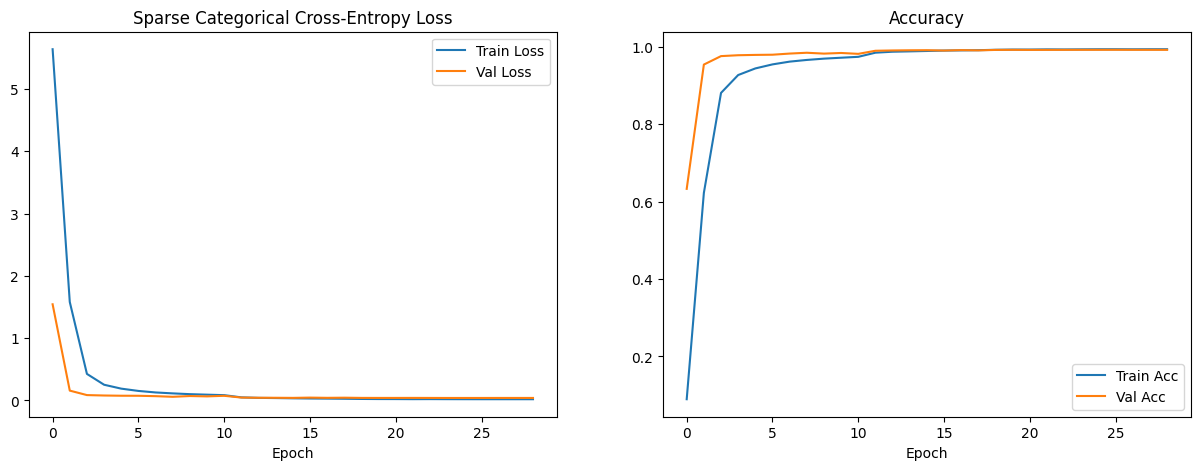

In [12]:
def ShowHistory(history):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Sparse Categorical Cross-Entropy Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.show()

ShowHistory(history)

### Model Testing and Analysis

In [13]:
def TestModel(model, test_X, test_y):
    
    preds = model.predict(test_X)  
    preds = np.argmax(preds, axis=1)

    print(f"Accuracy: {accuracy_score(test_y, preds):.4f}")
    print("Classification Report:")
    print(classification_report(test_y, preds))
    
    return preds

y_pred = TestModel(model, test_X, test_y)

1956/1956 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
Accuracy: 0.9923
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       0.74      0.85      0.79        20
           4       1.00      1.00      1.00        21
           5       1.00      1.00      1.00        20
           6       1.00      0.95      0.97        20
           7       1.00      0.90      0.95        20
           8       1.00      0.90      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        21
          12       0.95      1.00      0.98        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       0.95      1.00      0.98        

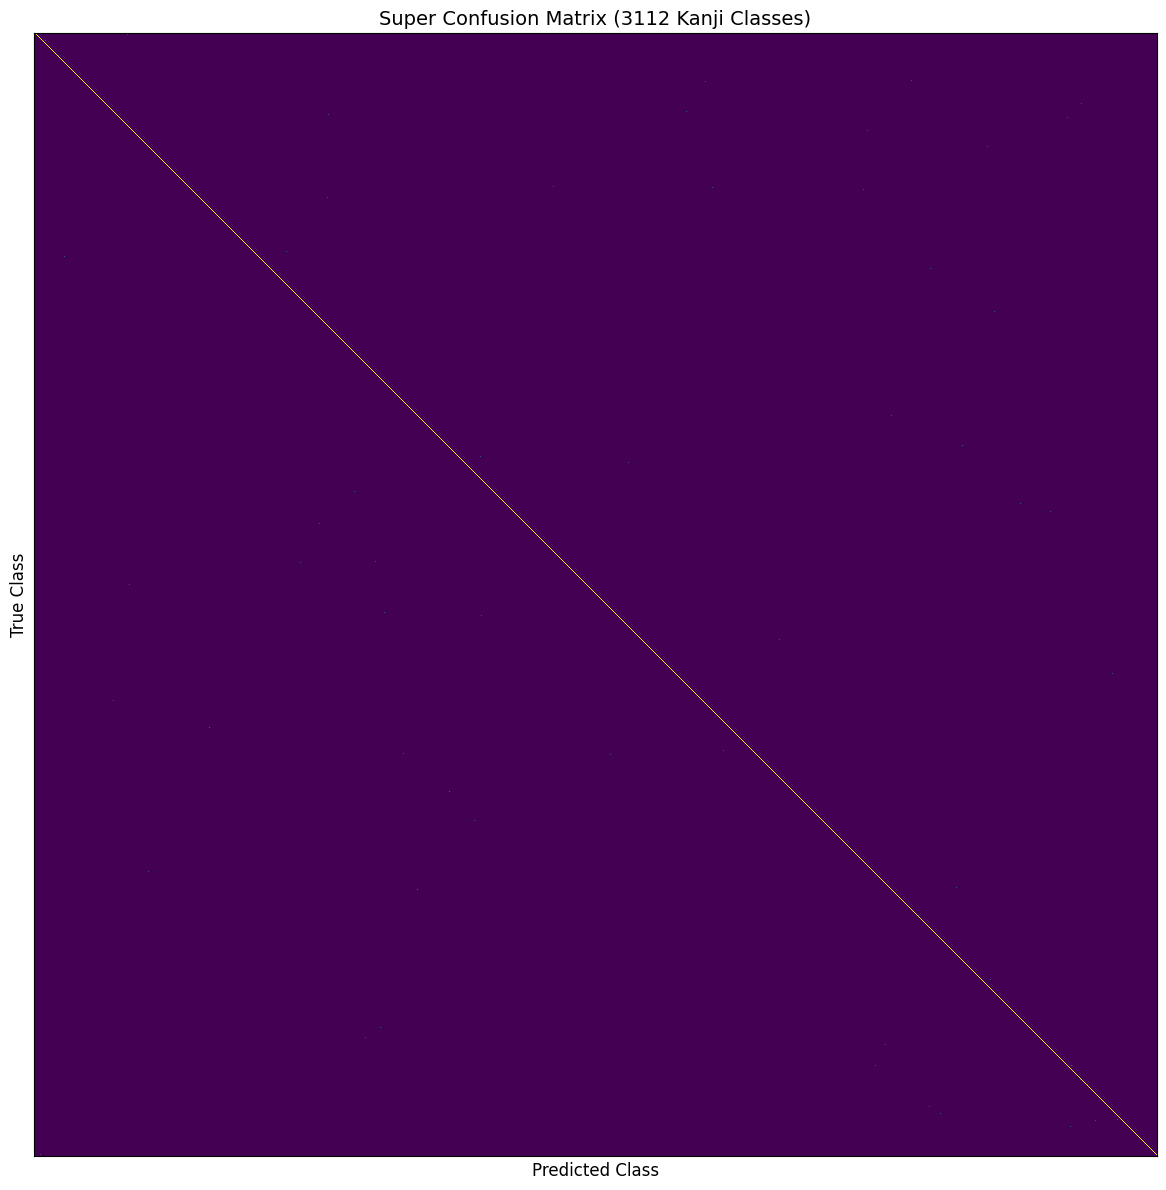

In [14]:
#This is not really usefull but it looks cool

def SuperMegaConfusionMatrix(test_y, preds):

    cm = confusion_matrix(test_y, preds)
    
    im, ax = plt.subplots(figsize=(12, 12))

    ax.imshow(np.log1p(cm), cmap='viridis', interpolation='nearest')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    
    plt.title(f"Super Confusion Matrix ({cm.shape[0]} Kanji Classes)", fontsize=14)
    plt.xlabel("Predicted Class", fontsize=12)
    plt.ylabel("True Class", fontsize=12)
    
    plt.tight_layout()
    plt.show()

SuperMegaConfusionMatrix(test_y, y_pred)

In [15]:
#Very interesting results
#Definetely mention in final report

def TopMistakes(test_y, preds, n):

    cm = confusion_matrix(test_y, preds)
    
    np.fill_diagonal(cm, 0)
    
    topID = np.argsort(cm.flatten())[-n:][::-1]
    
    print(f"--- Top {n} Most Confused Kanjis ---")
    for i in topID:
        trueID, predID = np.unravel_index(i, cm.shape)
        
        count = cm[trueID, predID]
        trueKanji = Number2Letter.get(str(trueID))
        predKanji = Number2Letter.get(str(predID))
        
        print(f"True: {trueKanji} | Predicted: {predKanji} | Count: {count}")

TopMistakes(test_y, y_pred, 20)

--- Top 20 Most Confused Kanjis ---
True: 之 | Predicted: え | Count: 6
True: ベ | Predicted: べ | Count: 4
True: 鳥 | Predicted: 烏 | Count: 4
True: 己 | Predicted: 巳 | Count: 4
True: 麿 | Predicted: 磨 | Count: 3
True: え | Predicted: 之 | Count: 3
True: 乎 | Predicted: 平 | Count: 3
True: ヘ | Predicted: へ | Count: 3
True: 粟 | Predicted: 栗 | Count: 2
True: 帥 | Predicted: 師 | Count: 2
True: 幕 | Predicted: 募 | Count: 2
True: 簿 | Predicted: 薄 | Count: 2
True: 追 | Predicted: 迫 | Count: 2
True: 腎 | Predicted: 賢 | Count: 2
True: 伶 | Predicted: 怜 | Count: 2
True: 雀 | Predicted: 省 | Count: 2
True: 着 | Predicted: 看 | Count: 2
True: 綿 | Predicted: 線 | Count: 2
True: 末 | Predicted: 未 | Count: 2
True: 烏 | Predicted: 鳥 | Count: 2
